# *Credit Card Fraud Detection Project*

Project Goal- Predict whether a credit card transaction is fraudulent (1) or legitimate (0) using transaction attributes such as elapsed time, anonymized PCA components (V1 through V28), and transaction amount.

#*What the Notebook Covers (The Full ML Lifecycle)*
1. Problem Framing & Data Loading: Ingesting raw credit card data via kagglehub (mlg-ulb/creditcardfraud).                       
2. Exploratory Data Analysis (EDA): Quantifying extreme class imbalance, inspecting transaction amount distributions, and reviewing feature correlations.

3. Data Cleaning & Feature Engineering: Standardizing continuous variables (Amount and Time) while preserving privacy-protected PCA vectors (V1–V28).

4. Stratified Train / Test Split: Executing a stratified split (stratify=y) to maintain the scarce ratio of fraud cases across training and test subsets.

5. Preprocessing Pipeline: Constructing a modular ColumnTransformer to scale numerical parameters cleanly without data leakage.

6. Baseline Model: Establishing a standard Logistic Regression benchmark.

7. Multiple Candidate Algorithms: Benchmarking multiple classifiers (Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting / XGBoost).

8. Handling Class Imbalance: Implementing cost-sensitive learning via class_weight='balanced' or tree-specific scale weights.

9. Model Comparison & Evaluation Metrics: Moving past misleading accuracy metrics to prioritize Macro-F1, Precision-Recall AUC (PR-AUC), and Recall.

10. Hyperparameter Tuning: Optimizing thresholds and tree estimators using RandomizedSearchCV.

11. Final Evaluation: Assessing the tuned pipeline on the untouched test split via confusion matrices and classification reports.

12. Saving the Final Artifact: Serializing the complete preprocessor and model bundle into a production-ready file (Model_Pipeline.pkl) using joblib.

# *1. Import Libraries*

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    PrecisionRecallDisplay,
)

import joblib

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# *2.  Load The dataset*

#####*The raw CSV downloaded from Kaggle is read directly into a pandas DataFrame.*

In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "creditcard.csv"))
df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000,284807.0000
mean,94813.8596,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,88.3496,0.0017
std,47488.1460,1.9587,1.6513,1.5163,1.4159,1.3802,1.3323,1.2371,1.1944,1.0986,1.0888,1.0207,0.9992,0.9953,0.9586,0.9153,0.8763,0.8493,0.8382,0.8140,0.7709,0.7345,0.7257,0.6245,0.6056,0.5213,0.4822,0.4036,0.3301,250.1201,0.0415
min,0.0000,-56.4075,-72.7157,-48.3256,-5.6832,-113.7433,-26.1605,-43.5572,-73.2167,-13.4341,-24.5883,-4.7975,-18.6837,-5.7919,-19.2143,-4.4989,-14.1299,-25.1628,-9.4987,-7.2135,-54.4977,-34.8304,-10.9331,-44.8077,-2.8366,-10.2954,-2.6046,-22.5657,-15.4301,0.0000,0.0000
25%,54201.5000,-0.9204,-0.5985,-0.8904,-0.8486,-0.6916,-0.7683,-0.5541,-0.2086,-0.6431,-0.5354,-0.7625,-0.4056,-0.6485,-0.4256,-0.5829,-0.4680,-0.4837,-0.4988,-0.4563,-0.2117,-0.2284,-0.5424,-0.1618,-0.3546,-0.3171,-0.3270,-0.0708,-0.0530,5.6000,0.0000
50%,84692.0000,0.0181,0.0655,0.1798,-0.0198,-0.0543,-0.2742,0.0401,0.0224,-0.0514,-0.0929,-0.0328,0.1400,-0.0136,0.0506,0.0481,0.0664,-0.0657,-0.0036,0.0037,-0.0625,-0.0295,0.0068,-0.0112,0.0410,0.0166,-0.0521,0.0013,0.0112,22.0000,0.0000
75%,139320.5000,1.3156,0.8037,1.0272,0.7433,0.6119,0.3986,0.5704,0.3273,0.5971,0.4539,0.7396,0.6182,0.6625,0.4931,0.6488,0.5233,0.3997,0.5008,0.4589,0.1330,0.1864,0.5286,0.1476,0.4395,0.3507,0.2410,0.0910,0.0783,77.1650,0.0000
max,172792.0000,2.4549,22.0577,9.3826,16.8753,34.8017,73.3016,120.5895,20.0072,15.5950,23.7451,12.0189,7.8484,7.1269,10.5268,8.8777,17.3151,9.2535,5.0411,5.5920,39.4209,27.2028,10.5031,22.5284,4.5845,7.5196,3.5173,31.6122,33.8478,25691.1600,1.0000


In [6]:
df.shape

(284807, 31)

# *3. Exploratory Data Analysis (EDA)*

# *3.1 Missing Values*

In [7]:
print("Missing values in each column (Max):", df.isnull().sum().max())

Missing values in each column (Max): 0


# *3.2 Target Variable Imbalance (Fraud vs Legit)*

In [12]:
print("\nClass Distribution:")
print(df['Class'].value_counts(normalize=True) * 100)


Class Distribution:
Class
0   99.8273
1    0.1727
Name: proportion, dtype: float64


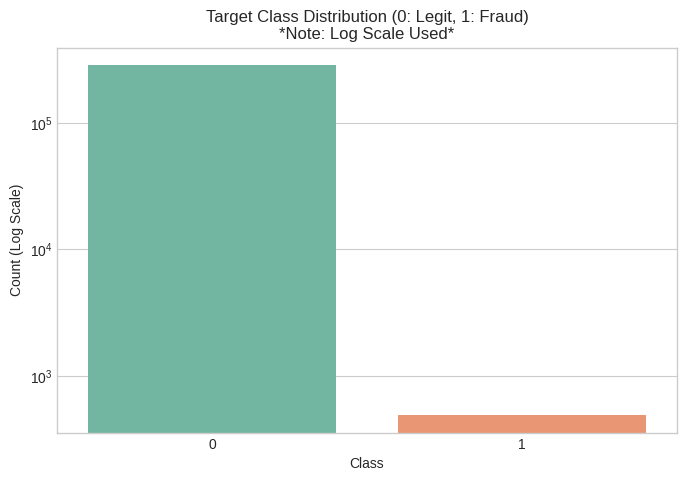

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Class', palette='Set2')
plt.title('Target Class Distribution (0: Legit, 1: Fraud)\n*Note: Log Scale Used*')
plt.yscale('log') # Essential for extreme imbalance
plt.ylabel('Count (Log Scale)')
plt.show()

# *3.3 Bivariate Analysis — Amount & Time vs Target*

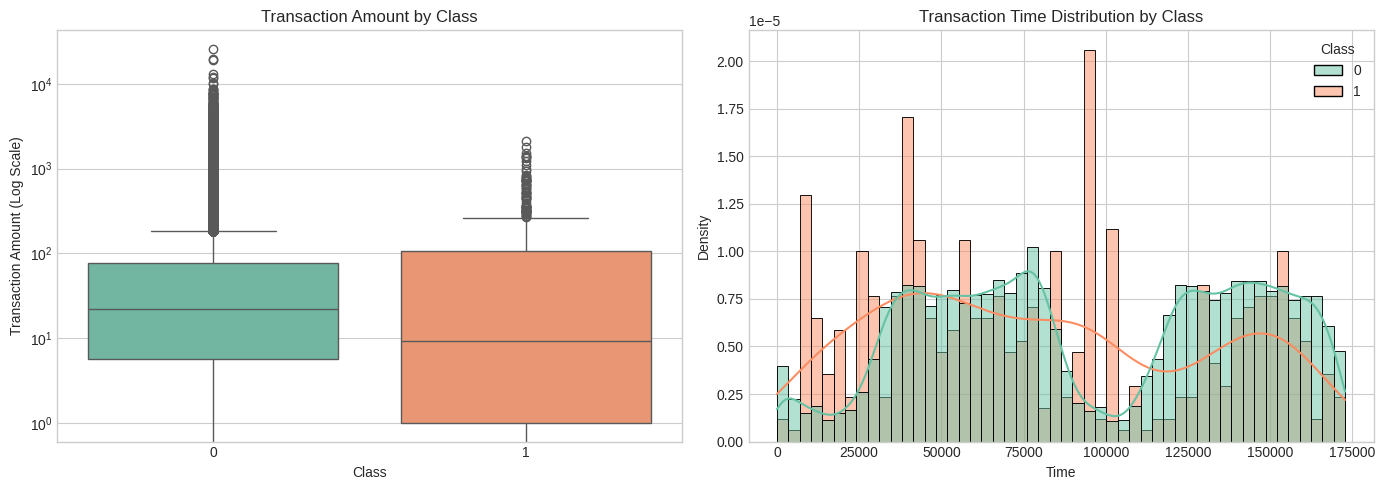

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Amount Distribution for Fraud vs Legit
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0], palette='Set2')
axes[0].set_title('Transaction Amount by Class')
axes[0].set_yscale('log') # Log scale due to extreme outliers in transaction amounts
axes[0].set_ylabel('Transaction Amount (Log Scale)')

# Plot 2: Time Distribution
sns.histplot(data=df, x='Time', hue='Class', bins=50, stat='density', common_norm=False, kde=True, ax=axes[1], palette='Set2')
axes[1].set_title('Transaction Time Distribution by Class')

plt.tight_layout()
plt.show()

# *3.4 Correlation Between Features*

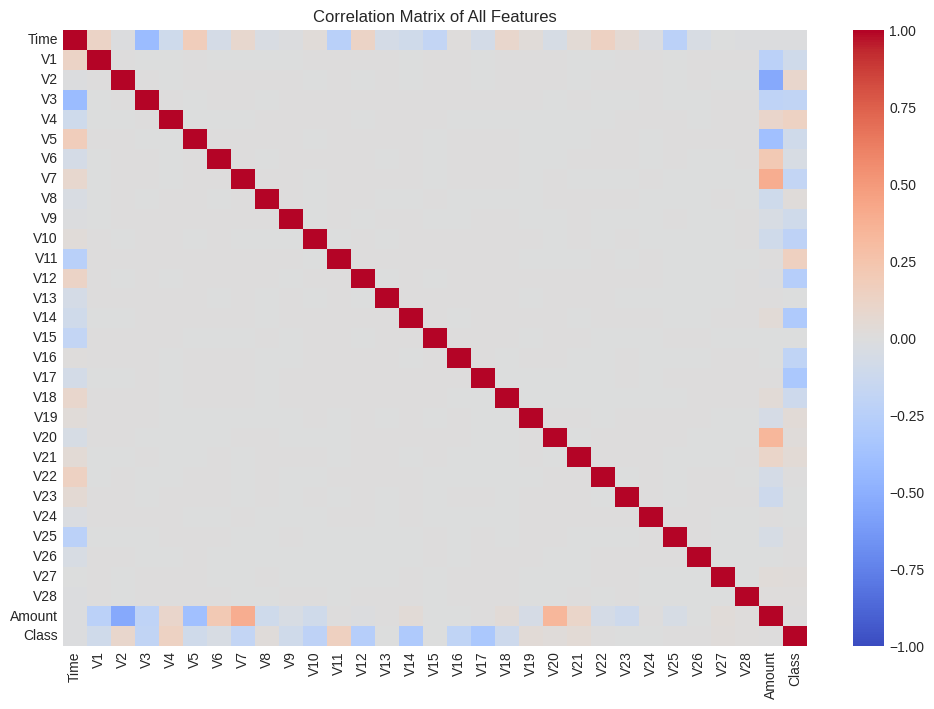

In [15]:
plt.figure(figsize=(12, 8))
corr = df.corr()
# We set annot=False because a 31x31 grid is too dense for annotations
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, vmin=-1, vmax=1)
plt.title('Correlation Matrix of All Features')
plt.show()

# *4. Data Preparation*

In [16]:
# Separate features (X) from the target (y)
X = df.drop(columns=['Class'])
y = df['Class']

# *5. Stratified Train / Test Split*

In [17]:
# We hold out 20% of the data as a test set.
# stratify=y is CRITICAL here to ensure the rare 0.17% fraud cases
# are proportionally distributed between the train and test sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print(f"\nFraud cases in Training set: {y_train.sum()} ({(y_train.sum()/len(y_train))*100:.3f}%)")
print(f"Fraud cases in Test set: {y_test.sum()} ({(y_test.sum()/len(y_test))*100:.3f}%)")

Training set shape: (227845, 30)
Test set shape: (56962, 30)

Fraud cases in Training set: 394 (0.173%)
Fraud cases in Test set: 98 (0.172%)


# *6. Preprocessing: ColumnTransformer + Pipeline*

In [18]:
# V1-V28 are already PCA-transformed (centered/scaled).
# We only need to scale 'Amount' and 'Time'.

cols_to_scale = ['Time', 'Amount']

# Create the preprocessor
# We use 'passthrough' for the remainder (V1-V28) so they are kept as-is.
preprocessor = ColumnTransformer(
    transformers=[
        ('robust_scaler', RobustScaler(), cols_to_scale)
    ],
    remainder='passthrough'
)

# Display the preprocessor architecture
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('robust_scaler', RobustScaler(),
                                 ['Time', 'Amount'])])

# *7. Model Comparison & Baseline*

In [19]:
# We use 3-fold Stratified CV to evaluate models on the training data.
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def evaluate_model(model, X_train, y_train):
    """
    Chains the preprocessor and model into a single Pipeline,
    then evaluates it using Stratified CV.
    """
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Evaluate using PR-AUC (Average Precision) and Macro-F1
    # n_jobs=-1 uses all available CPU cores to speed up processing
    pr_auc_scores = cross_val_score(model_pipeline, X_train, y_train, cv=kf, scoring='average_precision', n_jobs=-1)
    f1_scores = cross_val_score(model_pipeline, X_train, y_train, cv=kf, scoring='f1_macro', n_jobs=-1)

    print(f"{model.__class__.__name__}:")
    print(f"  PR-AUC (Average Precision): {pr_auc_scores.mean():.4f} (+/- {pr_auc_scores.std():.4f})")
    print(f"  Macro-F1 Score:             {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})\n")

    return model_pipeline

# Initialize Baseline & Candidate Models
# class_weight='balanced' is applied to penalize missing the minority class (Fraud)
models = [
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42),
    RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=50, random_state=42)
]

print("Evaluating Baseline and Candidate Models (using 3-Fold Stratified CV)...\n")
for m in models:
    evaluate_model(m, X_train, y_train)

Evaluating Baseline and Candidate Models (using 3-Fold Stratified CV)...

LogisticRegression:
  PR-AUC (Average Precision): 0.7515 (+/- 0.0265)
  Macro-F1 Score:             0.5508 (+/- 0.0026)

DecisionTreeClassifier:
  PR-AUC (Average Precision): 0.3370 (+/- 0.1682)
  Macro-F1 Score:             0.5537 (+/- 0.0059)

RandomForestClassifier:
  PR-AUC (Average Precision): 0.7604 (+/- 0.0172)
  Macro-F1 Score:             0.7912 (+/- 0.0114)



# *8. Hyperparameter Tuning (Random Forest)*

In [22]:
print("Starting Hyperparameter Tuning for Random Forest...\n")

# Define the base pipeline with the winning algorithm
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Define the parameter grid
# Note: We use the 'classifier__' prefix to route parameters to the model inside the Pipeline
param_distributions = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# Initialize RandomizedSearchCV
# We optimize strictly for PR-AUC ('average_precision')
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=5, # Keeping n_iter small to respect Colab execution time limits
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    n_jobs=-1,
    random_state=42,
    verbose=2
)

# Execute the search on the training data
random_search.fit(X_train, y_train)

print("\n==========================================")
print("Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best CV PR-AUC Score: {random_search.best_score_:.4f}")
print("==========================================\n")

# Extract the final, optimized pipeline
best_model_pipeline = random_search.best_estimator_

Starting Hyperparameter Tuning for Random Forest...

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters Found:
  classifier__n_estimators: 100
  classifier__min_samples_split: 5
  classifier__min_samples_leaf: 1
  classifier__max_depth: 10
Best CV PR-AUC Score: 0.8205



# *9. Final Evaluation on Test Set*

In [23]:
print("Evaluating Best Model on Unseen Test Data...\n")

# Predict on the test set using the best pipeline
y_pred = best_model_pipeline.predict(X_test)
y_pred_proba = best_model_pipeline.predict_proba(X_test)[:, 1]

Evaluating Best Model on Unseen Test Data...



# *9.1 Classification Report*

In [24]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate (0)', 'Fraudulent (1)']))

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00     56864
Fraudulent (1)       0.79      0.83      0.81        98

      accuracy                           1.00     56962
     macro avg       0.90      0.91      0.90     56962
  weighted avg       1.00      1.00      1.00     56962



# *9.2 Confusion Matrix*

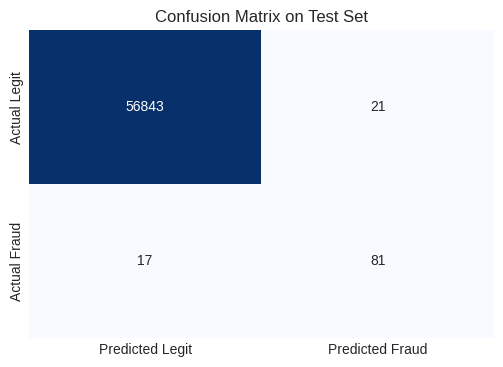

In [25]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title('Confusion Matrix on Test Set')
plt.show()

# *9.3 Precision-Recall Curve*

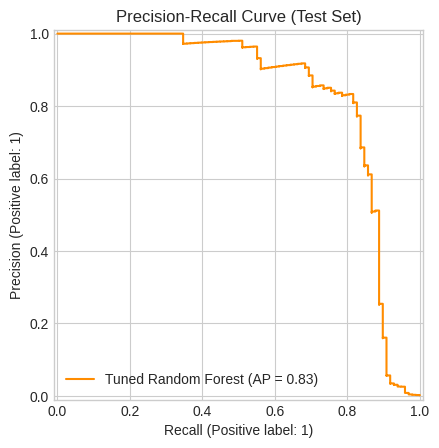

In [26]:
display = PrecisionRecallDisplay.from_estimator(
    best_model_pipeline, X_test, y_test, name="Tuned Random Forest", color="darkorange"
)
_ = display.ax_.set_title("Precision-Recall Curve (Test Set)")
plt.show()

# *10. Saving the Final Production Artifact*

In [27]:
# We save the ENTIRE best_model_pipeline (Preprocessor + Tuned Random Forest)
# This ensures that when we load it in production, we can pass raw data
# directly into the pipeline without manual scaling steps.

import os
import joblib

artifact_name = 'Model_Pipeline.pkl'
joblib.dump(best_model_pipeline, artifact_name)

print(f"\nSuccess! Production artifact '{artifact_name}' has been saved.")
print(f"File size: {os.path.getsize(artifact_name) / (1024 * 1024):.2f} MB")


Success! Production artifact 'Model_Pipeline.pkl' has been saved.
File size: 1.62 MB
